In [54]:
import matplotlib.colors as mcolors

def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying RGB values.
    factor < 1 → darker
    """
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

from matplotlib.lines import Line2D

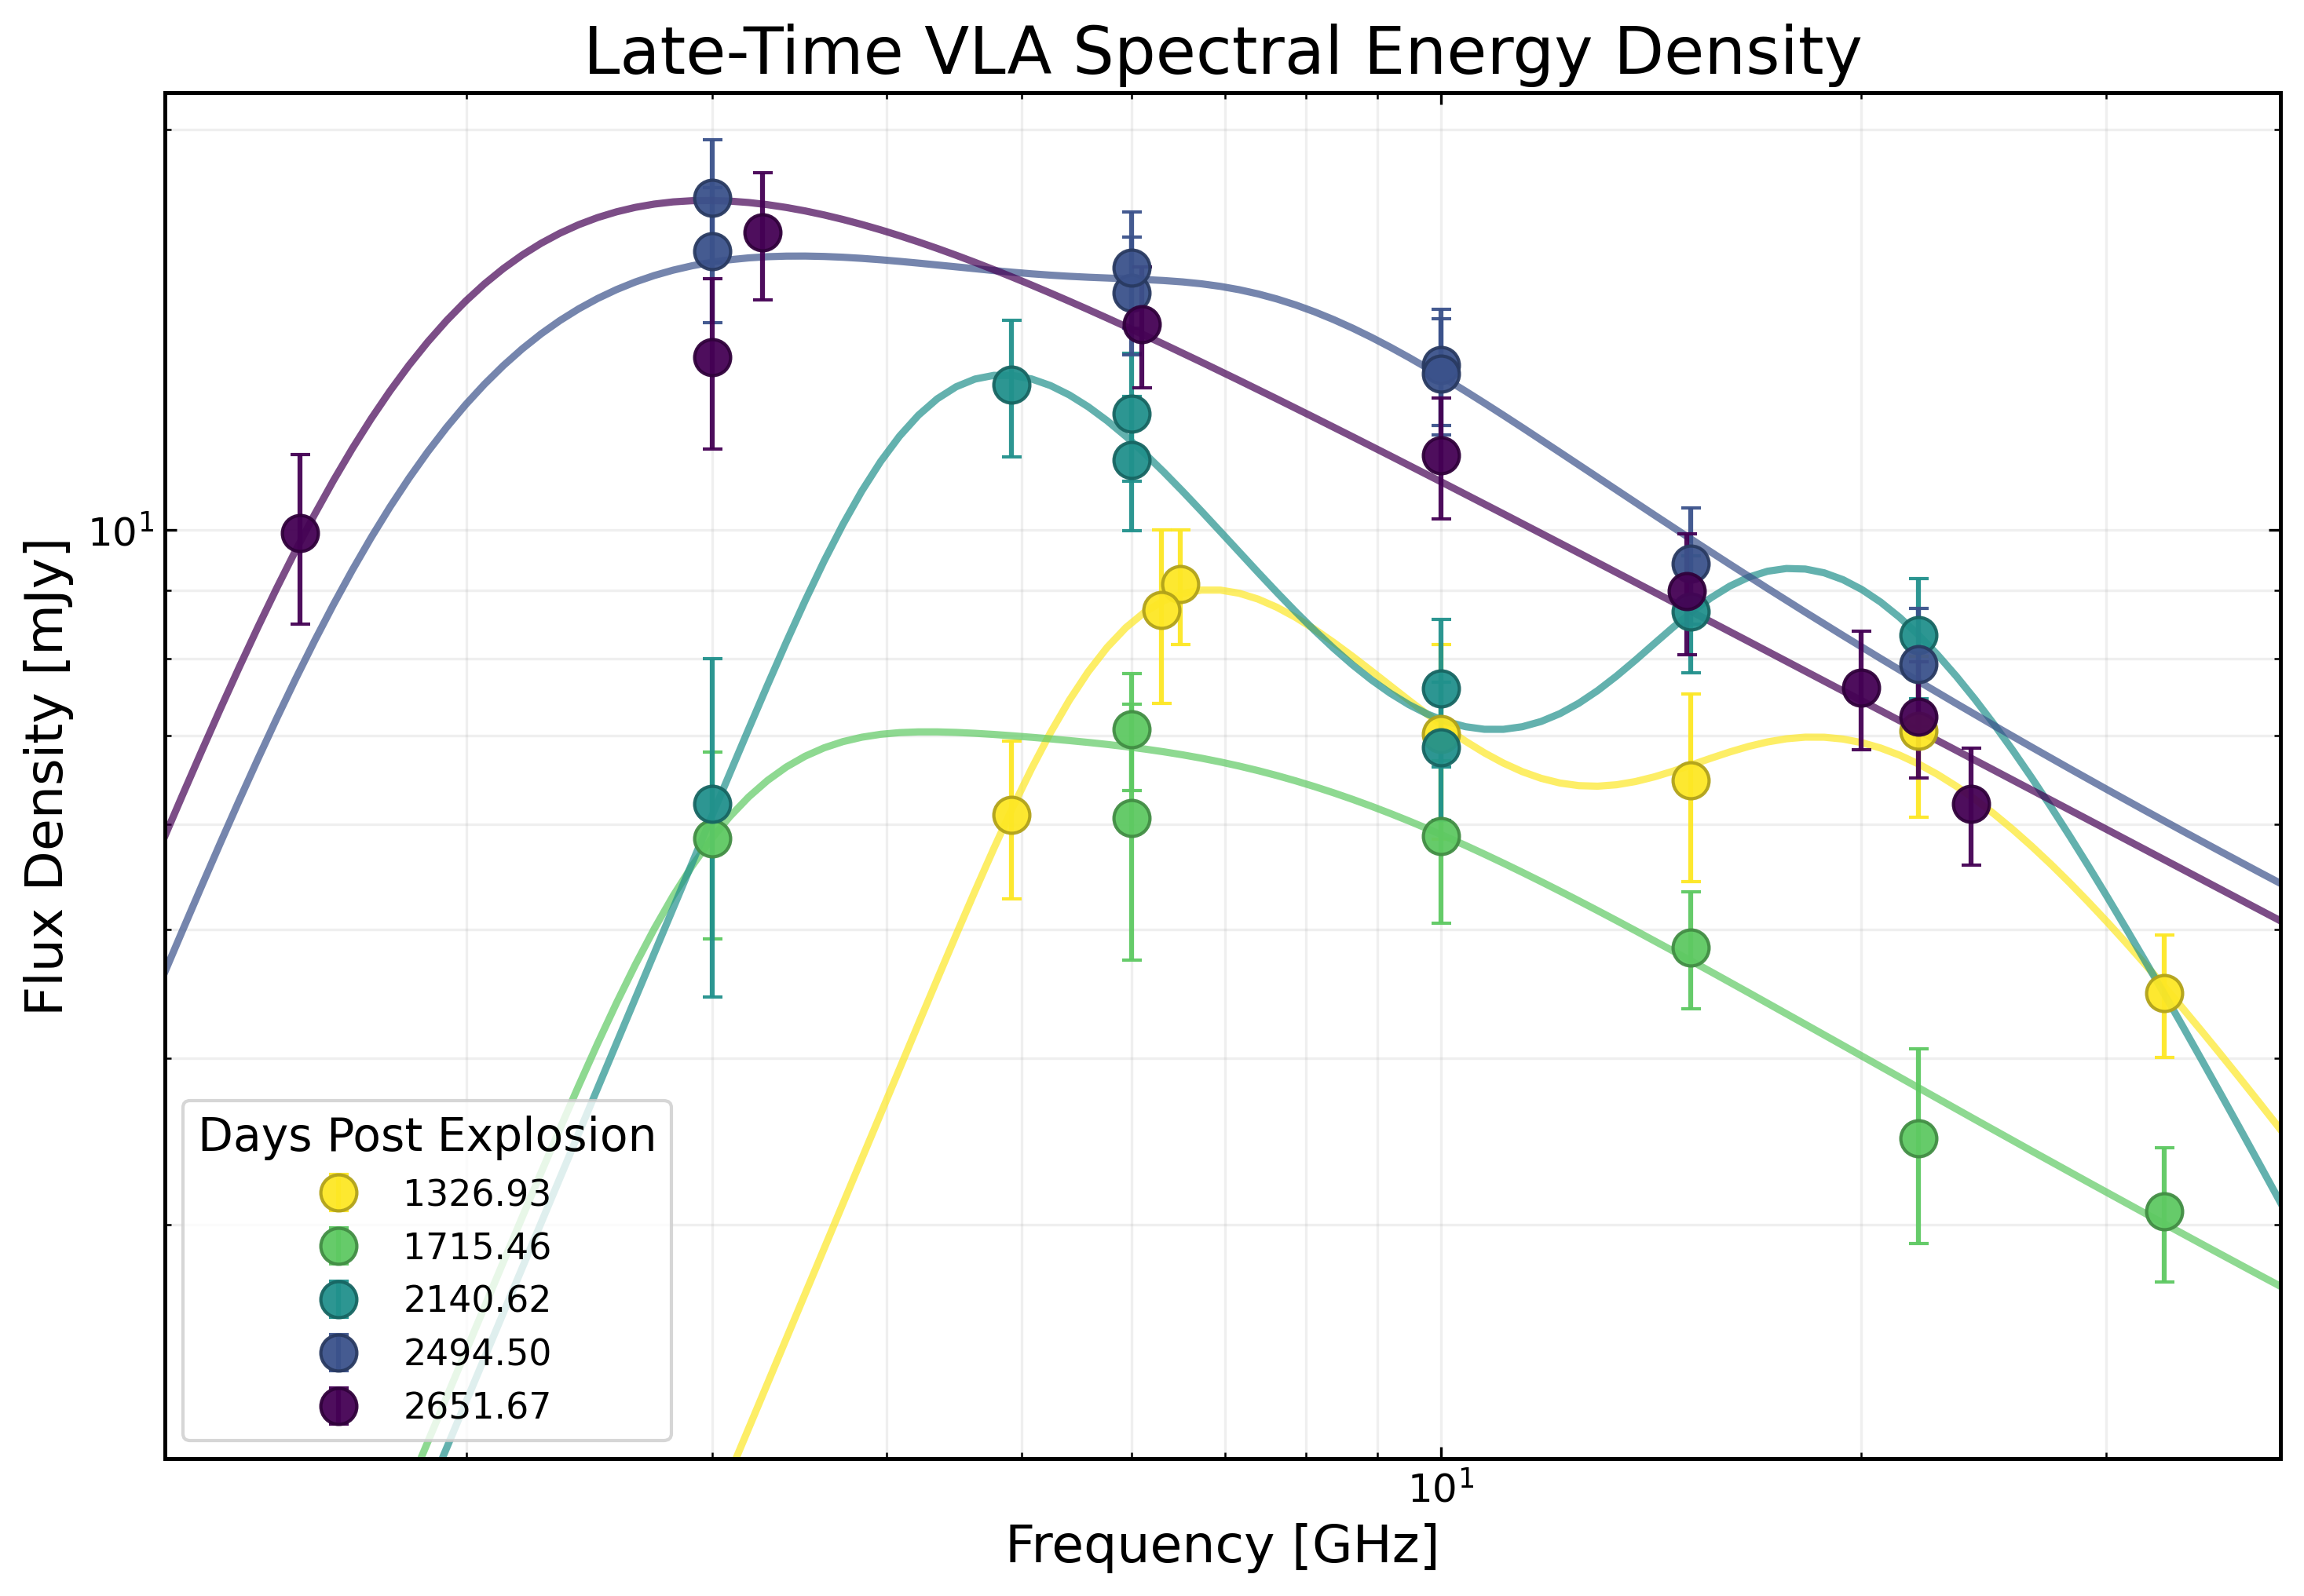

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import functions

# --- Load data ---
data = pd.read_csv("data/radio_18ivc_data.csv")

# --- Epoch info: epoch label, phase lower, phase upper, fit file ---
epoch_info = [
    (1300.0, 1200, 1400, "model_params/best_fit_params_1300.0_days.csv"),
    (1700.0, 1600, 1800, "model_params/best_fit_params_1700.0_days.csv"),
    (2100.0, 2000, 2200, "model_params/best_fit_params_2100.0_days.csv"),
    (2500.0, 2350, 2550, "model_params/best_fit_params_2500.0_days.csv"),
    (2650.0, 2550, 2750, "model_params/best_fit_params_2650.0_days.csv"),
]

# --- Style ---
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info, colors):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

plt.show()

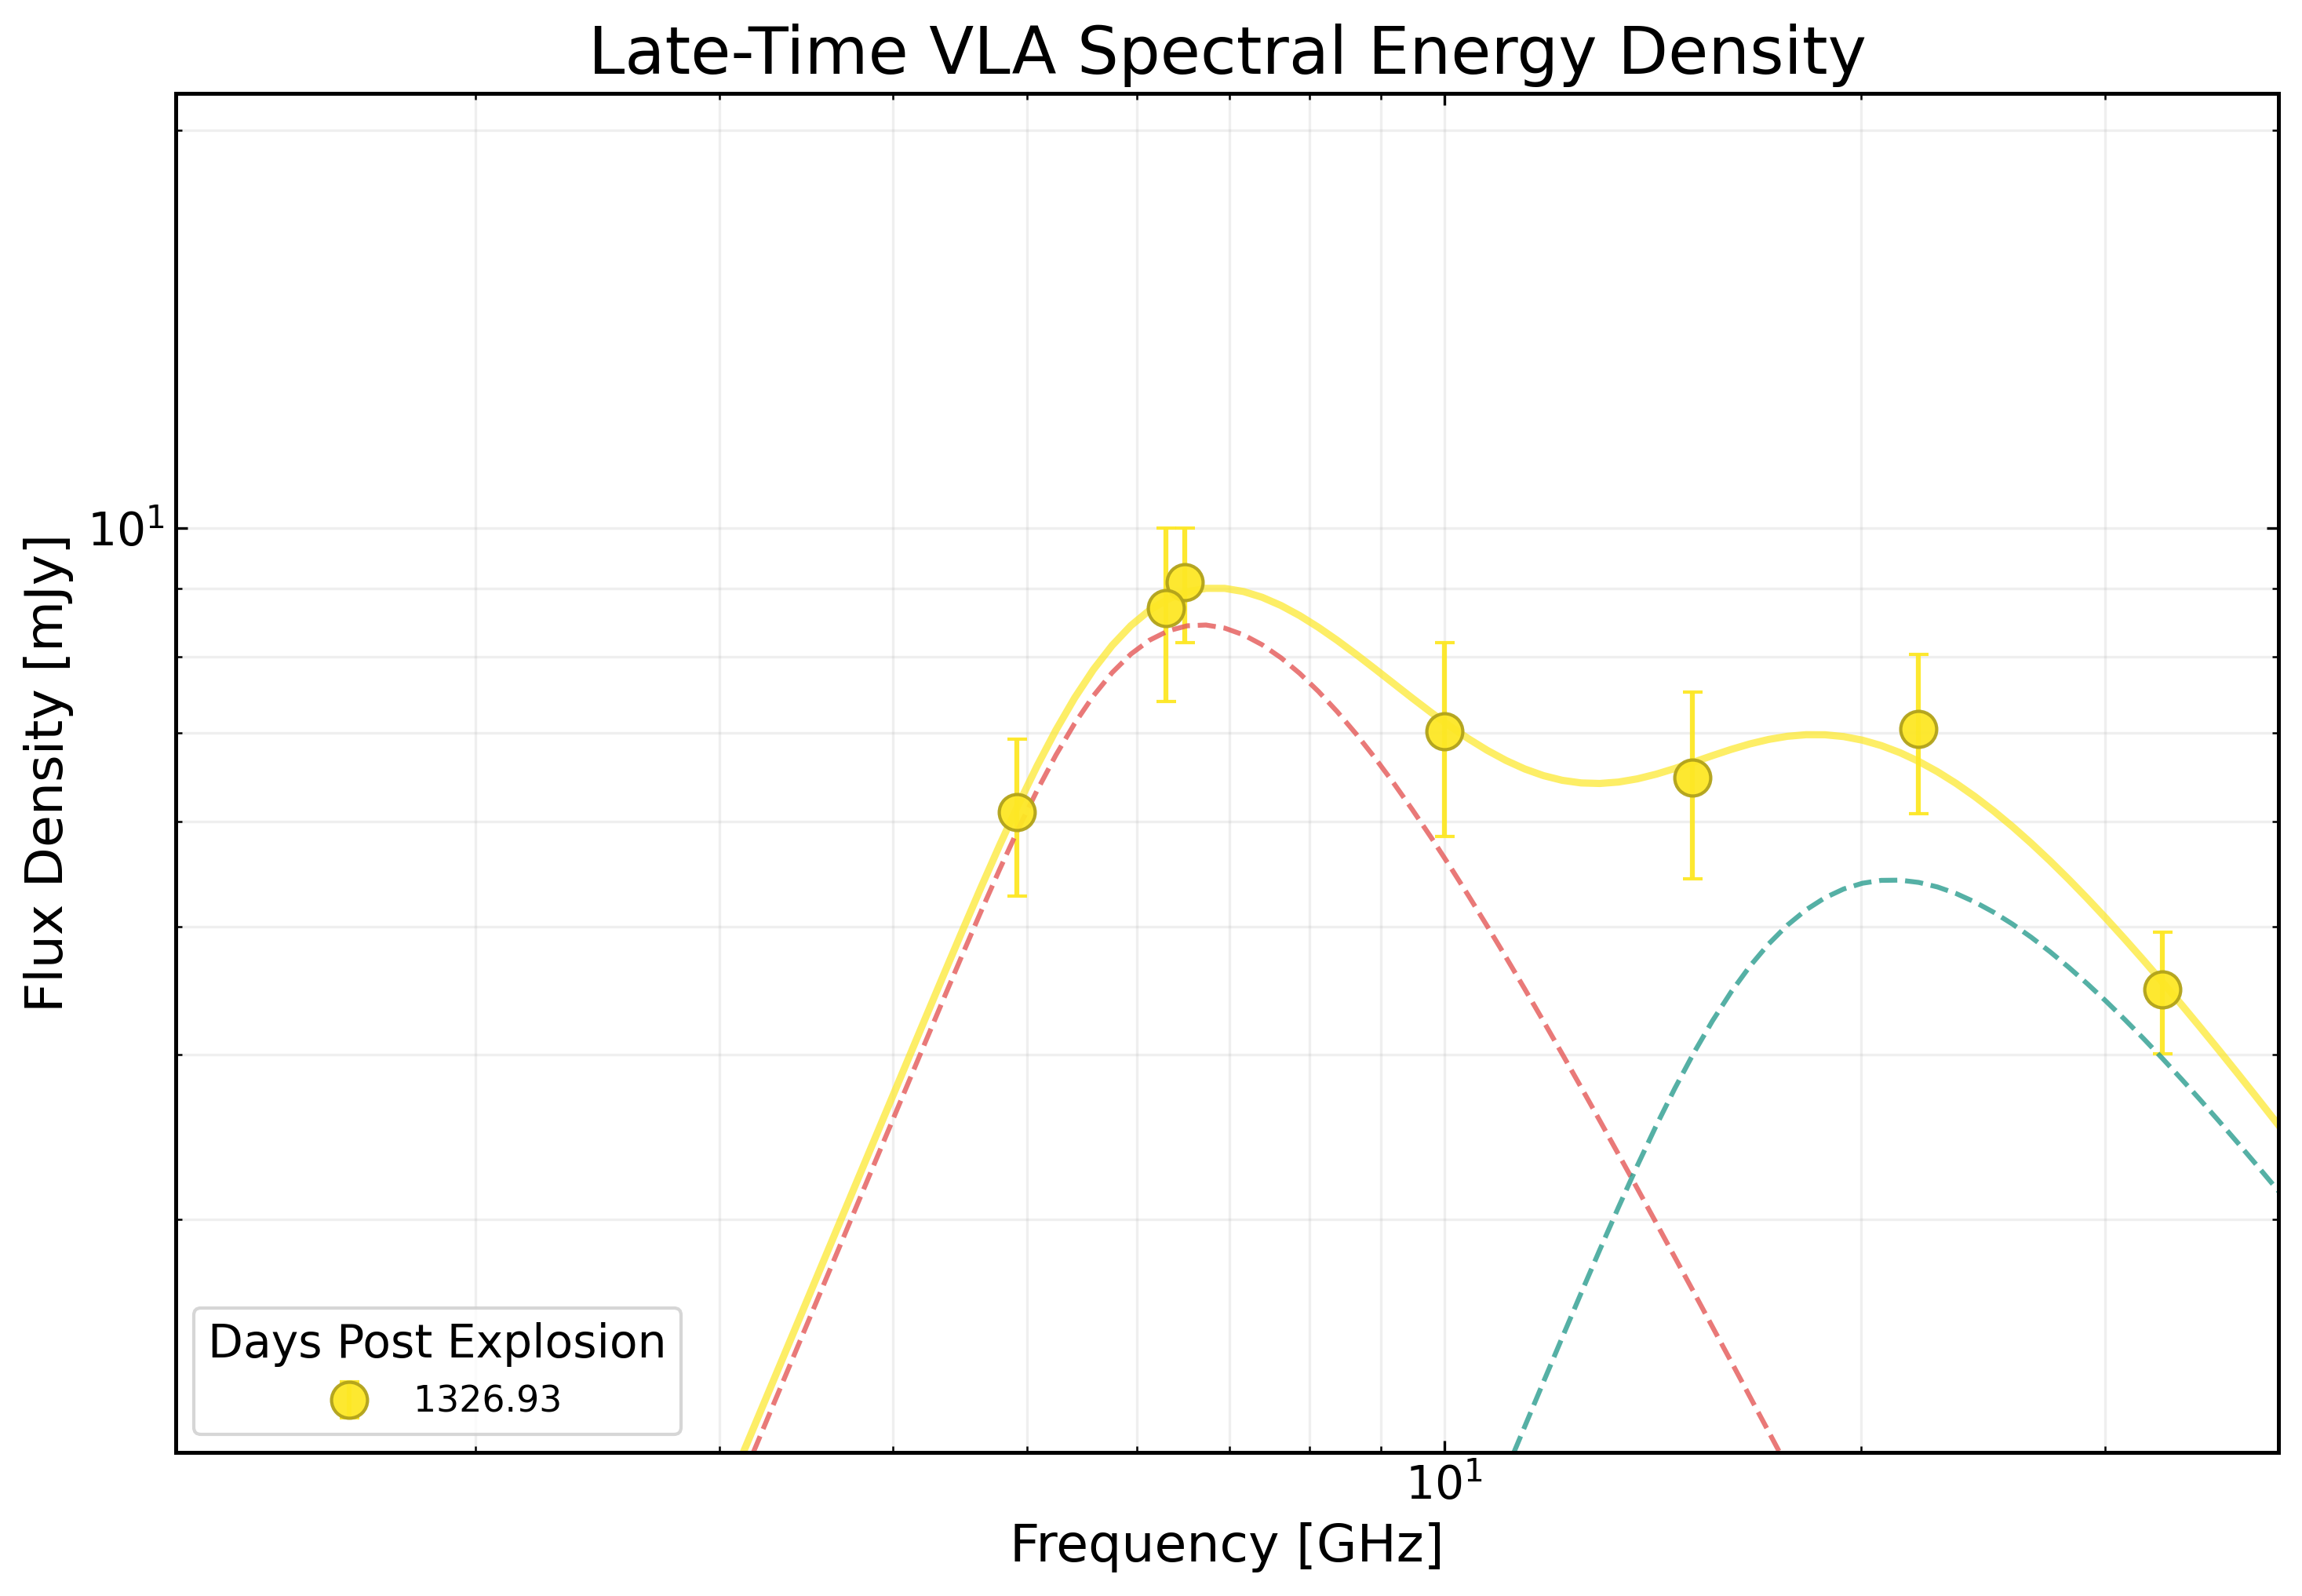

In [56]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:1], colors[:1]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

# plot the individual SSA components for the first epoch
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 8.44397724245342,6.782679571348622,4.999999999999997), 
        color='#E45756', ls='--', alpha=0.8, label="Component 1")
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 5.390828461554526,20.05438971340149,3.783907567649094), 
        color='#2A9D8F', ls='--', alpha=0.8, label="Component 2")

plt.show()

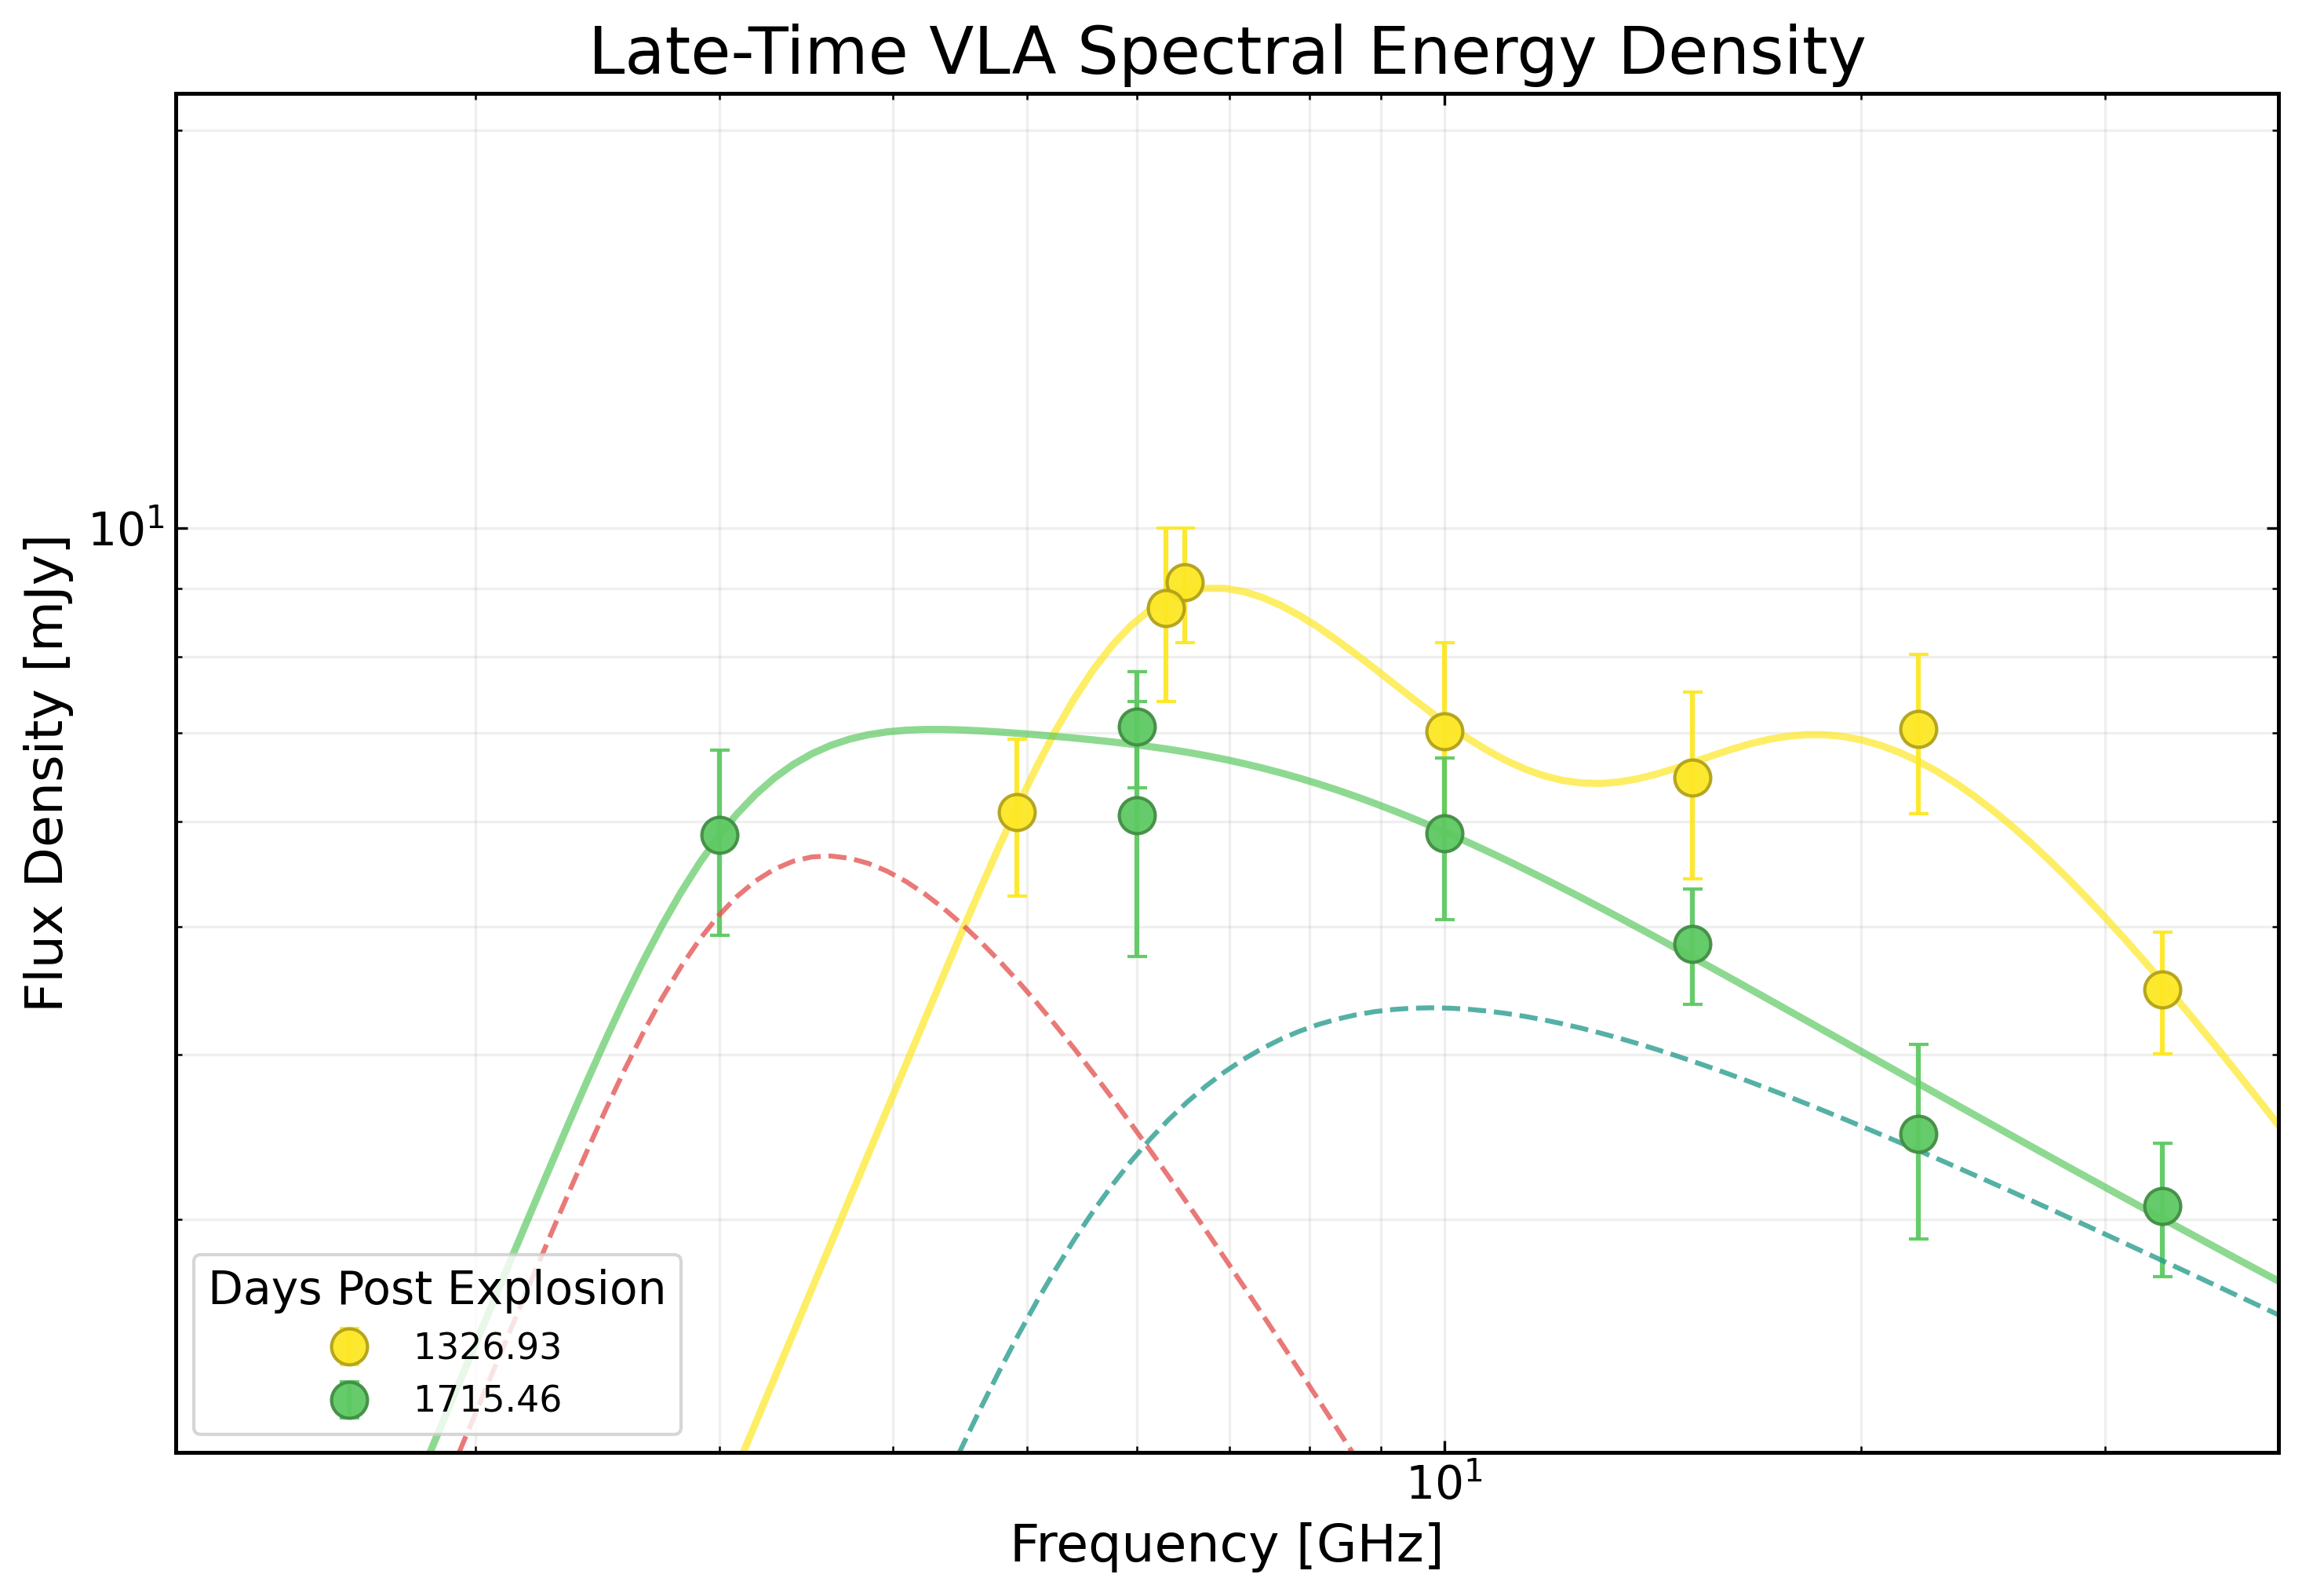

In [37]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:2], colors[:2]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

# plot the individual SSA components for the first epoch
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 5.650142307272045,3.542448907893012,4.352396091522126), 
        color='#E45756', ls='--', alpha=0.8, label="Component 1")
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 3.8722016614391706,6.924837077816746,2.0000000000008984), 
        color='#2A9D8F', ls='--', alpha=0.8, label="Component 2")
plt.show()

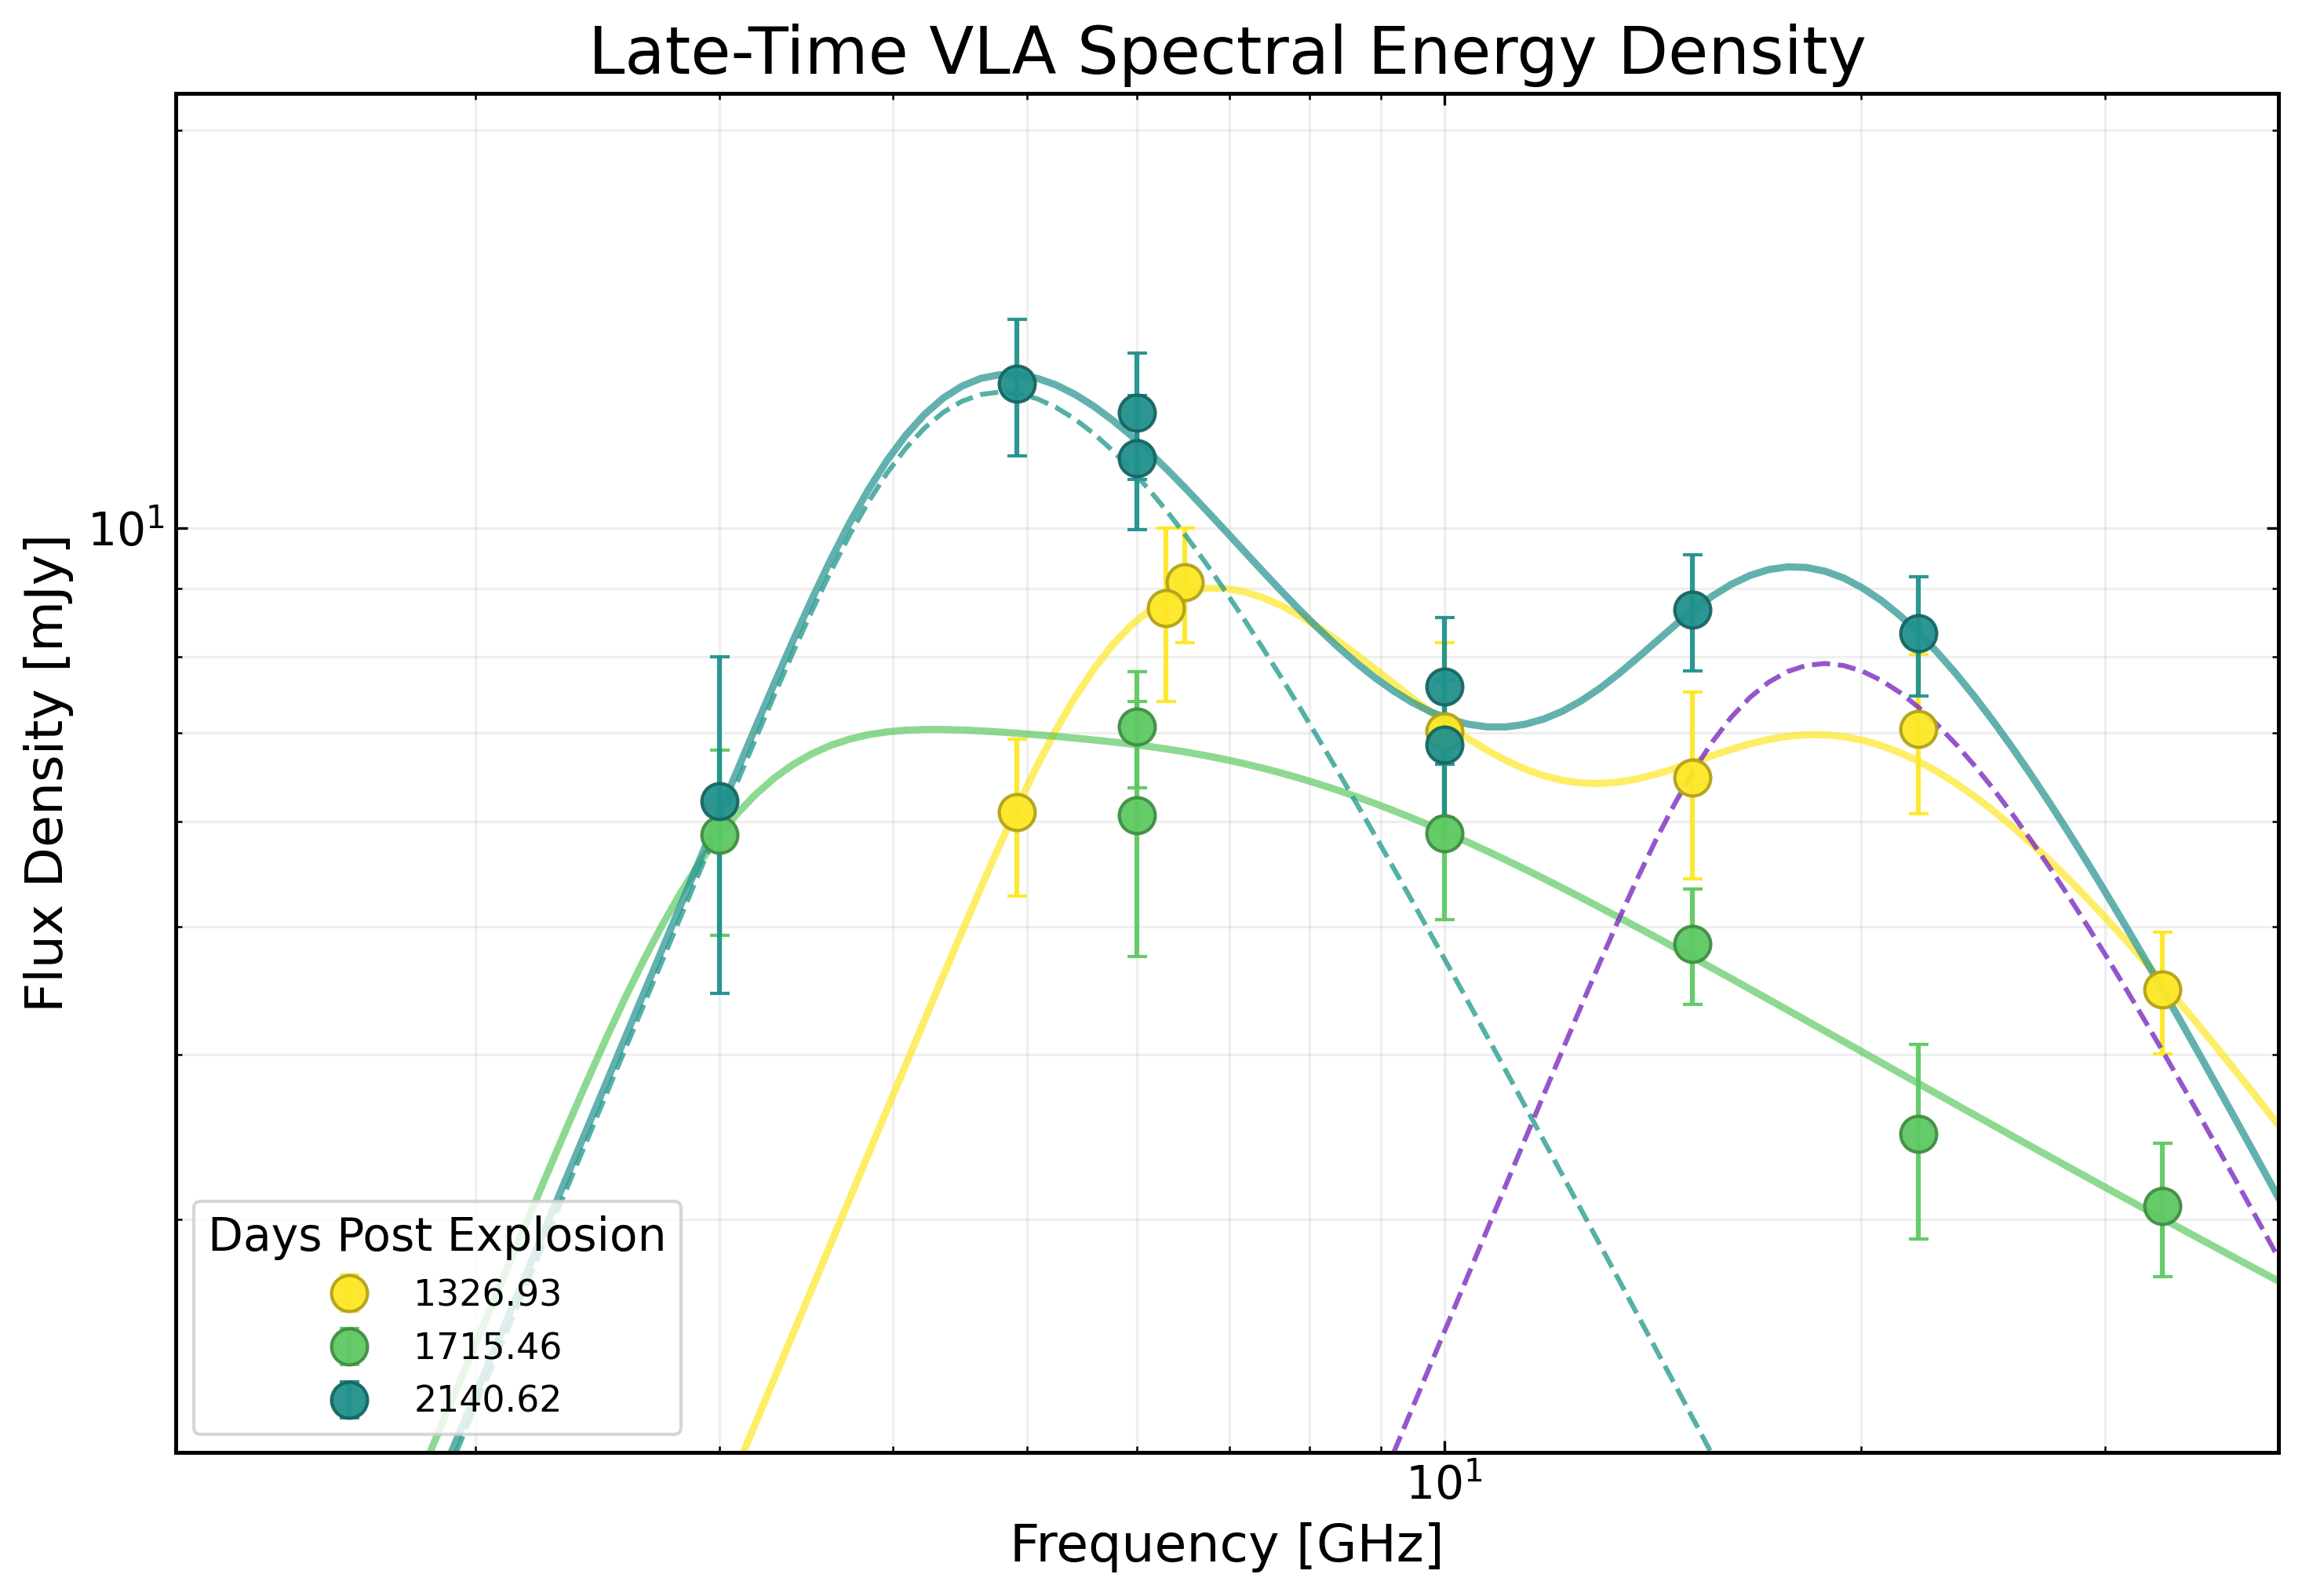

In [47]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:3], colors[:3]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

# plot the individual SSA components for the first epoch
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 12.666491962990392,4.868843341487093,4.956659969496957), 
        color='#2A9D8F', ls='--', alpha=0.8, label="Component 2")
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 7.8940387389930065,19.135074867724068,4.999999999999999), 
        color='#7B2CBF', ls='--', alpha=0.8, label="Component 3")
plt.show()

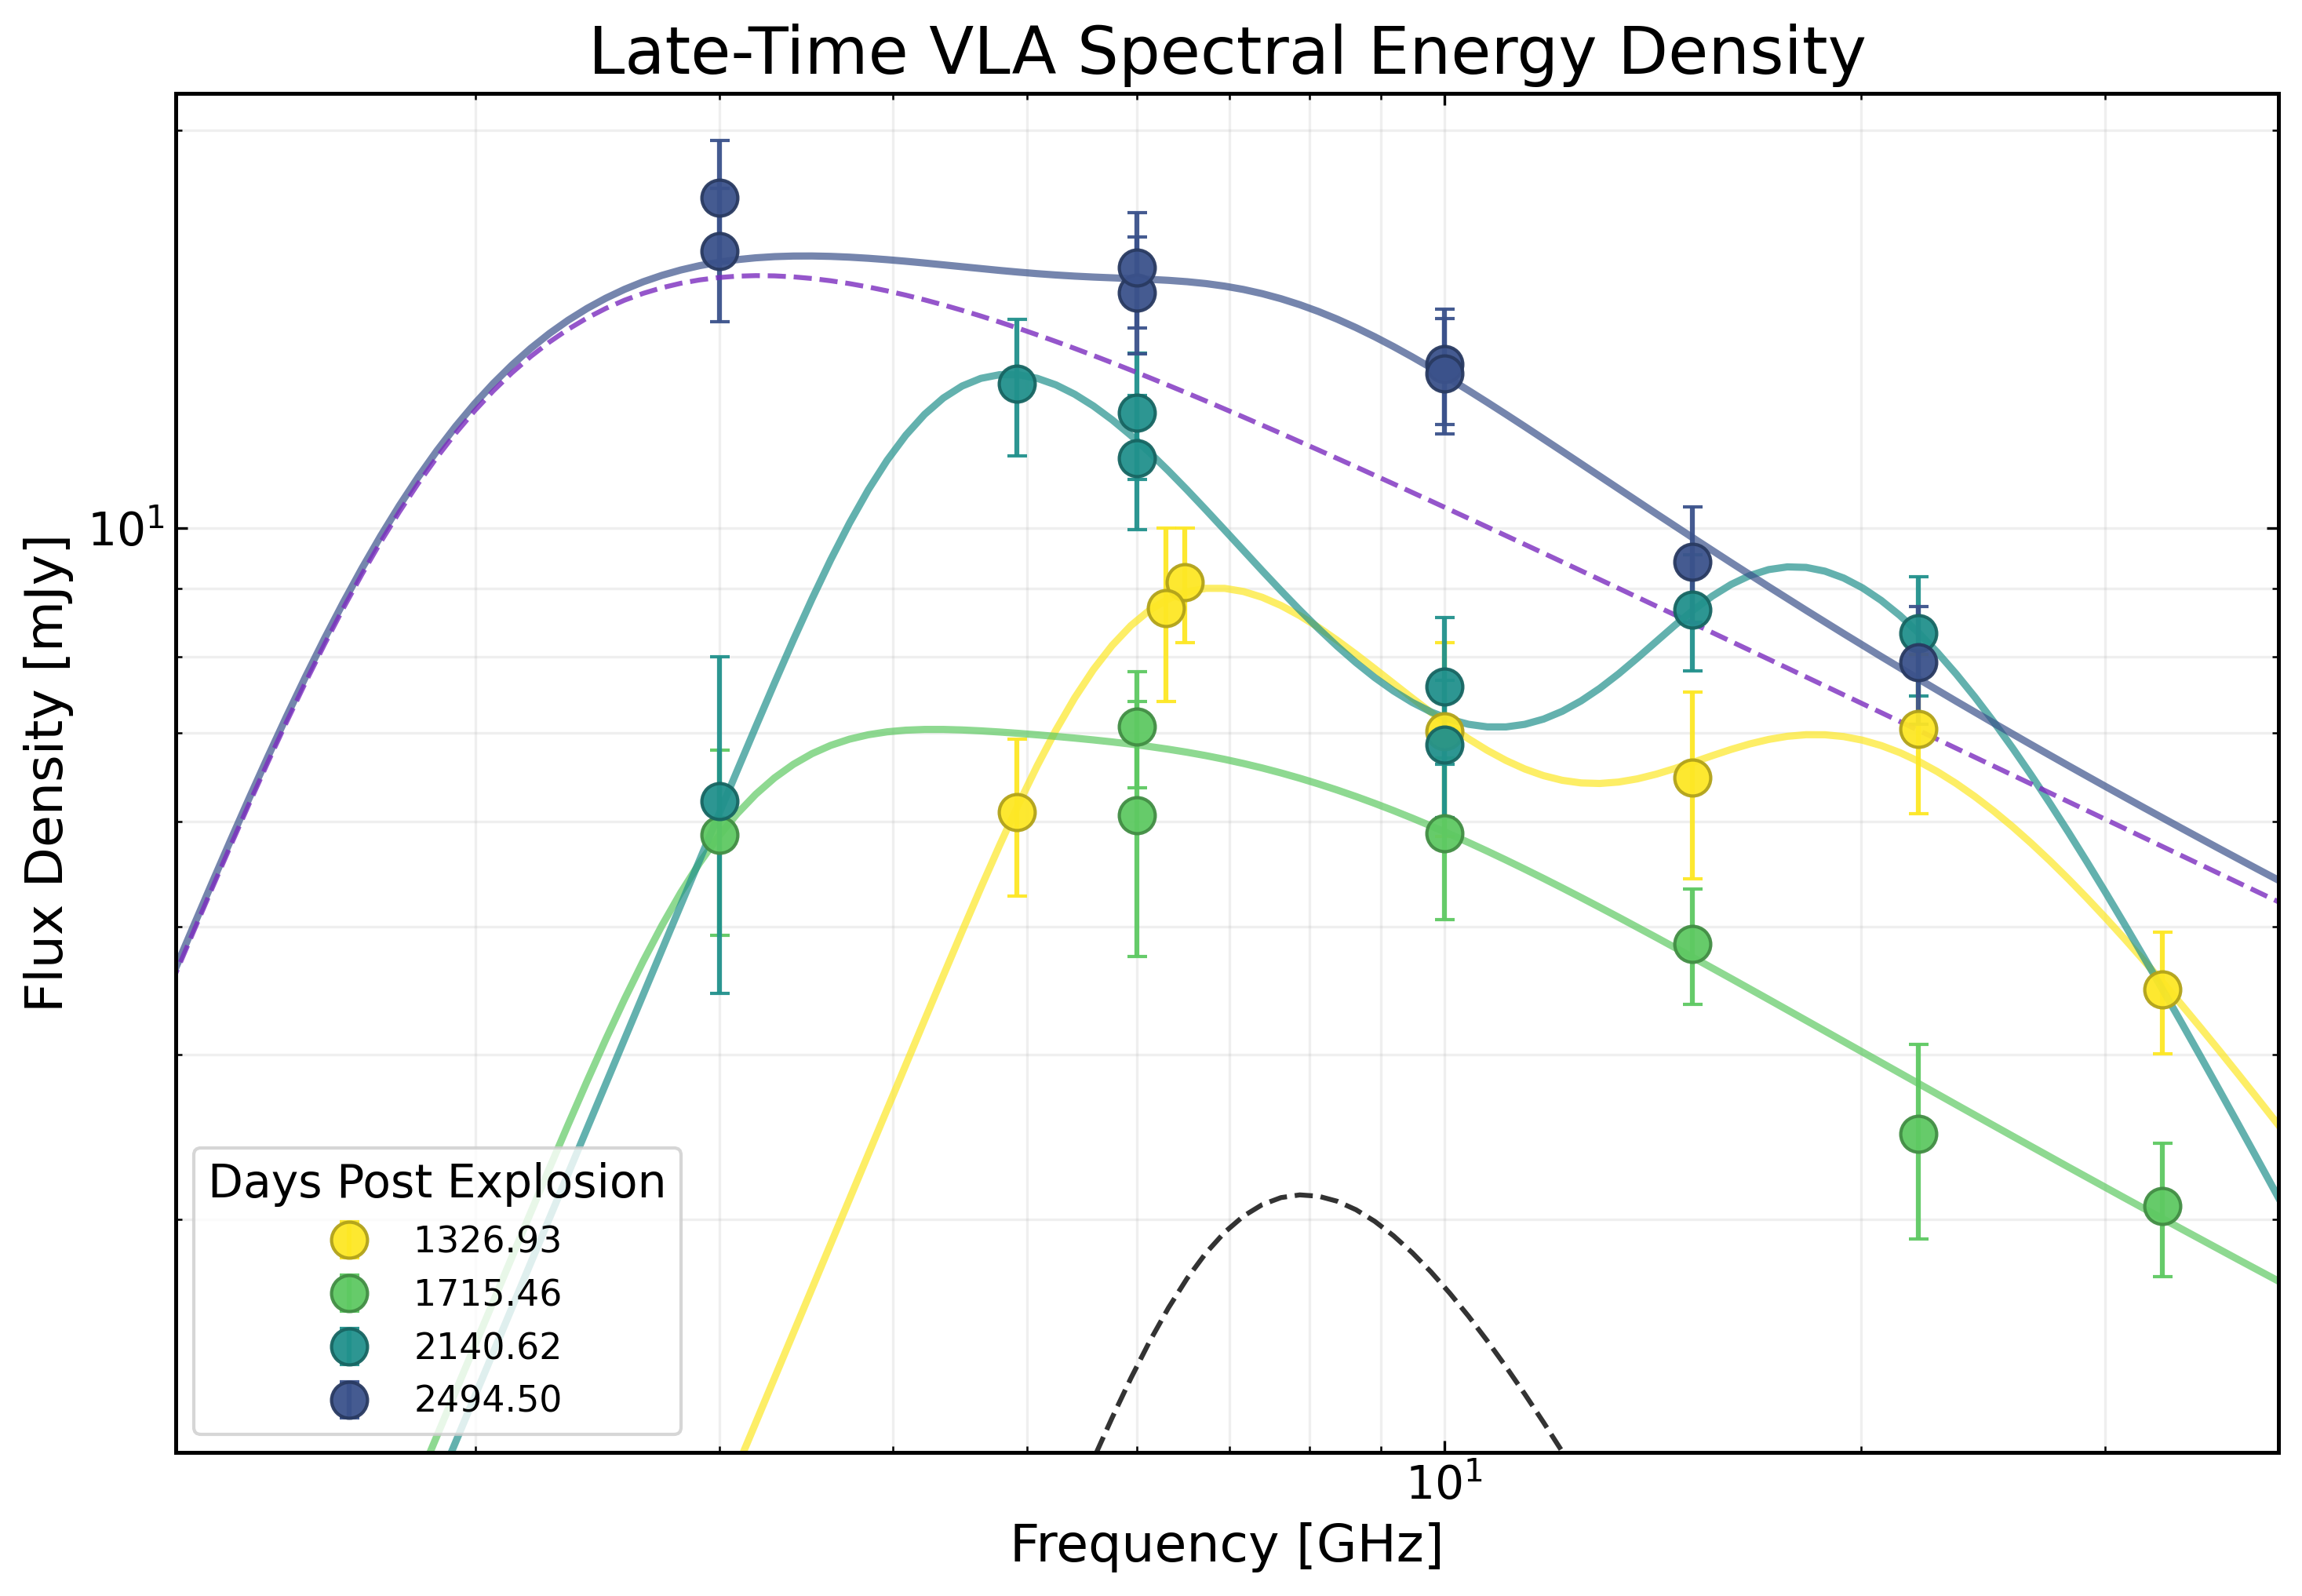

In [50]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:4], colors[:4]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

# plot the individual SSA components for the first epoch
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 13.855598352273423,2.2674048428453606,2.0000000000000004), 
        color='#7B2CBF', ls='--', alpha=0.8, label="Component 3")
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 3.129679551297325,8.043498213081852,4.999999999999999), 
        color='k', ls='--', alpha=0.8, label="Component 4")
plt.show()

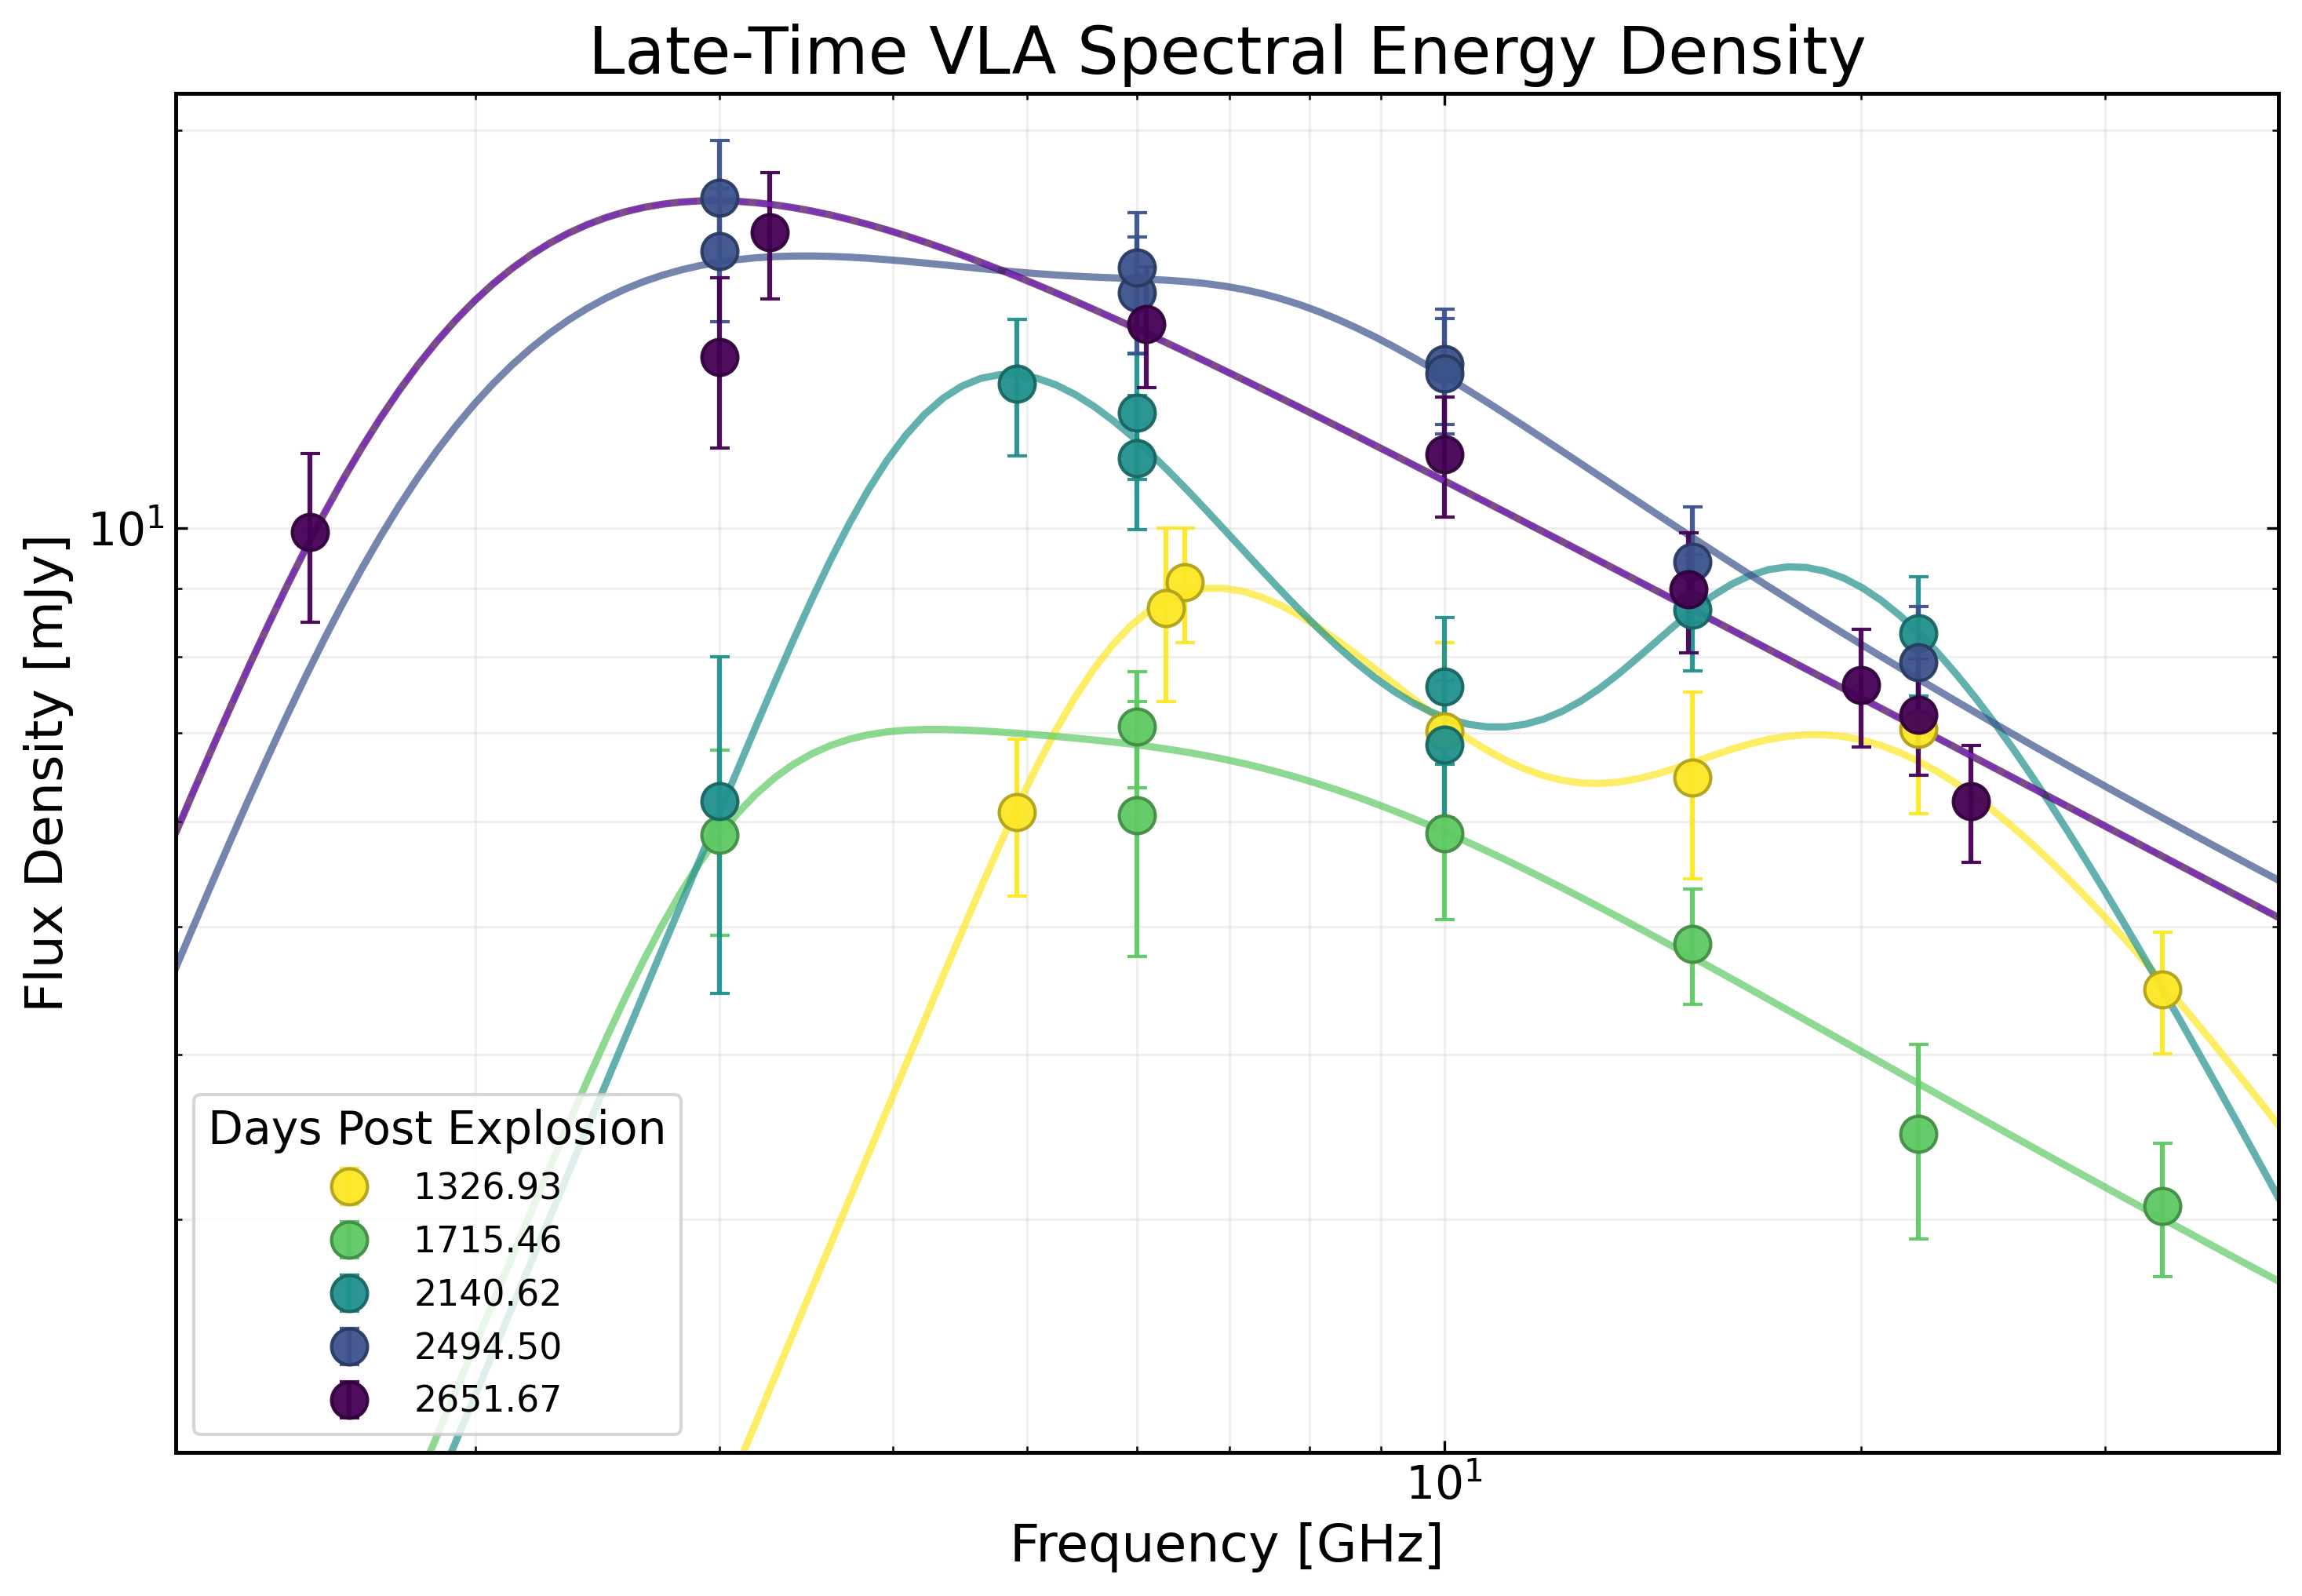

In [52]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(1, 0, len(epoch_info))]

freq_range = np.logspace(np.log10(min(data["freq"])*0.5), np.log10(max(data["freq"])*1.5), 200)

for (epoch, ph_lo, ph_hi, param_file), color in zip(epoch_info[:5], colors[:5]):

    # data for this epoch
    d_epoch = data[(data["phase"] >= ph_lo) & (data["phase"] <= ph_hi)]
    avg_phase = d_epoch["phase"].mean()

    edge_color = darken_color(color, 0.7)
    ax.errorbar(
        d_epoch["freq"],
        d_epoch["flux"],
        yerr=d_epoch["flux_err"],
        fmt="o",
        ms=11,
        capsize=3,
        elinewidth=1.5,
        color=color,
        markeredgecolor=edge_color,
        alpha=0.95,
        label=f"{avg_phase:.2f}"
    )

    # best-fit model for this epoch
    params_df = pd.read_csv(param_file)

    total_fit = np.zeros_like(freq_range)

    for _, row in params_df.iterrows():
        total_fit += functions.F_SSA_Nayana(
            freq_range,
            row["F_p (mJy)"],
            row["nu_p (GHz)"],
            row["p"]
        )

    ax.plot(freq_range, total_fit, color=color, lw=2.2, alpha=0.7)

# --- Axes ---
ax.set_xscale("log")
ax.set_yscale("log")
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
ax.set_xlim(x_sed[0], 40)
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))
ax.set_ylim(2, y_lims[1])

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux Density [mJy]")
ax.set_title("Late-Time VLA Spectral Energy Density")

ax.legend(title="Days Post Explosion", loc="lower left", frameon=True)
ax.grid(True, which='both', alpha=0.2)
#ax.grid(False, which='minor')

fig.tight_layout()
# fig.savefig("sn2018ivc_seds_with_fits.png", bbox_inches="tight", dpi=300)
# fig.savefig("sn2018ivc_seds_with_fits.pdf", bbox_inches="tight")

# plot the individual SSA components for the first epoch
ax.plot(freq_range, functions.F_SSA_Nayana(freq_range, 16.01219376601599,2.17731177474123,2.1041442641418464), 
        color='#7B2CBF', ls='--', alpha=0.8, label="Component 3")
plt.show()

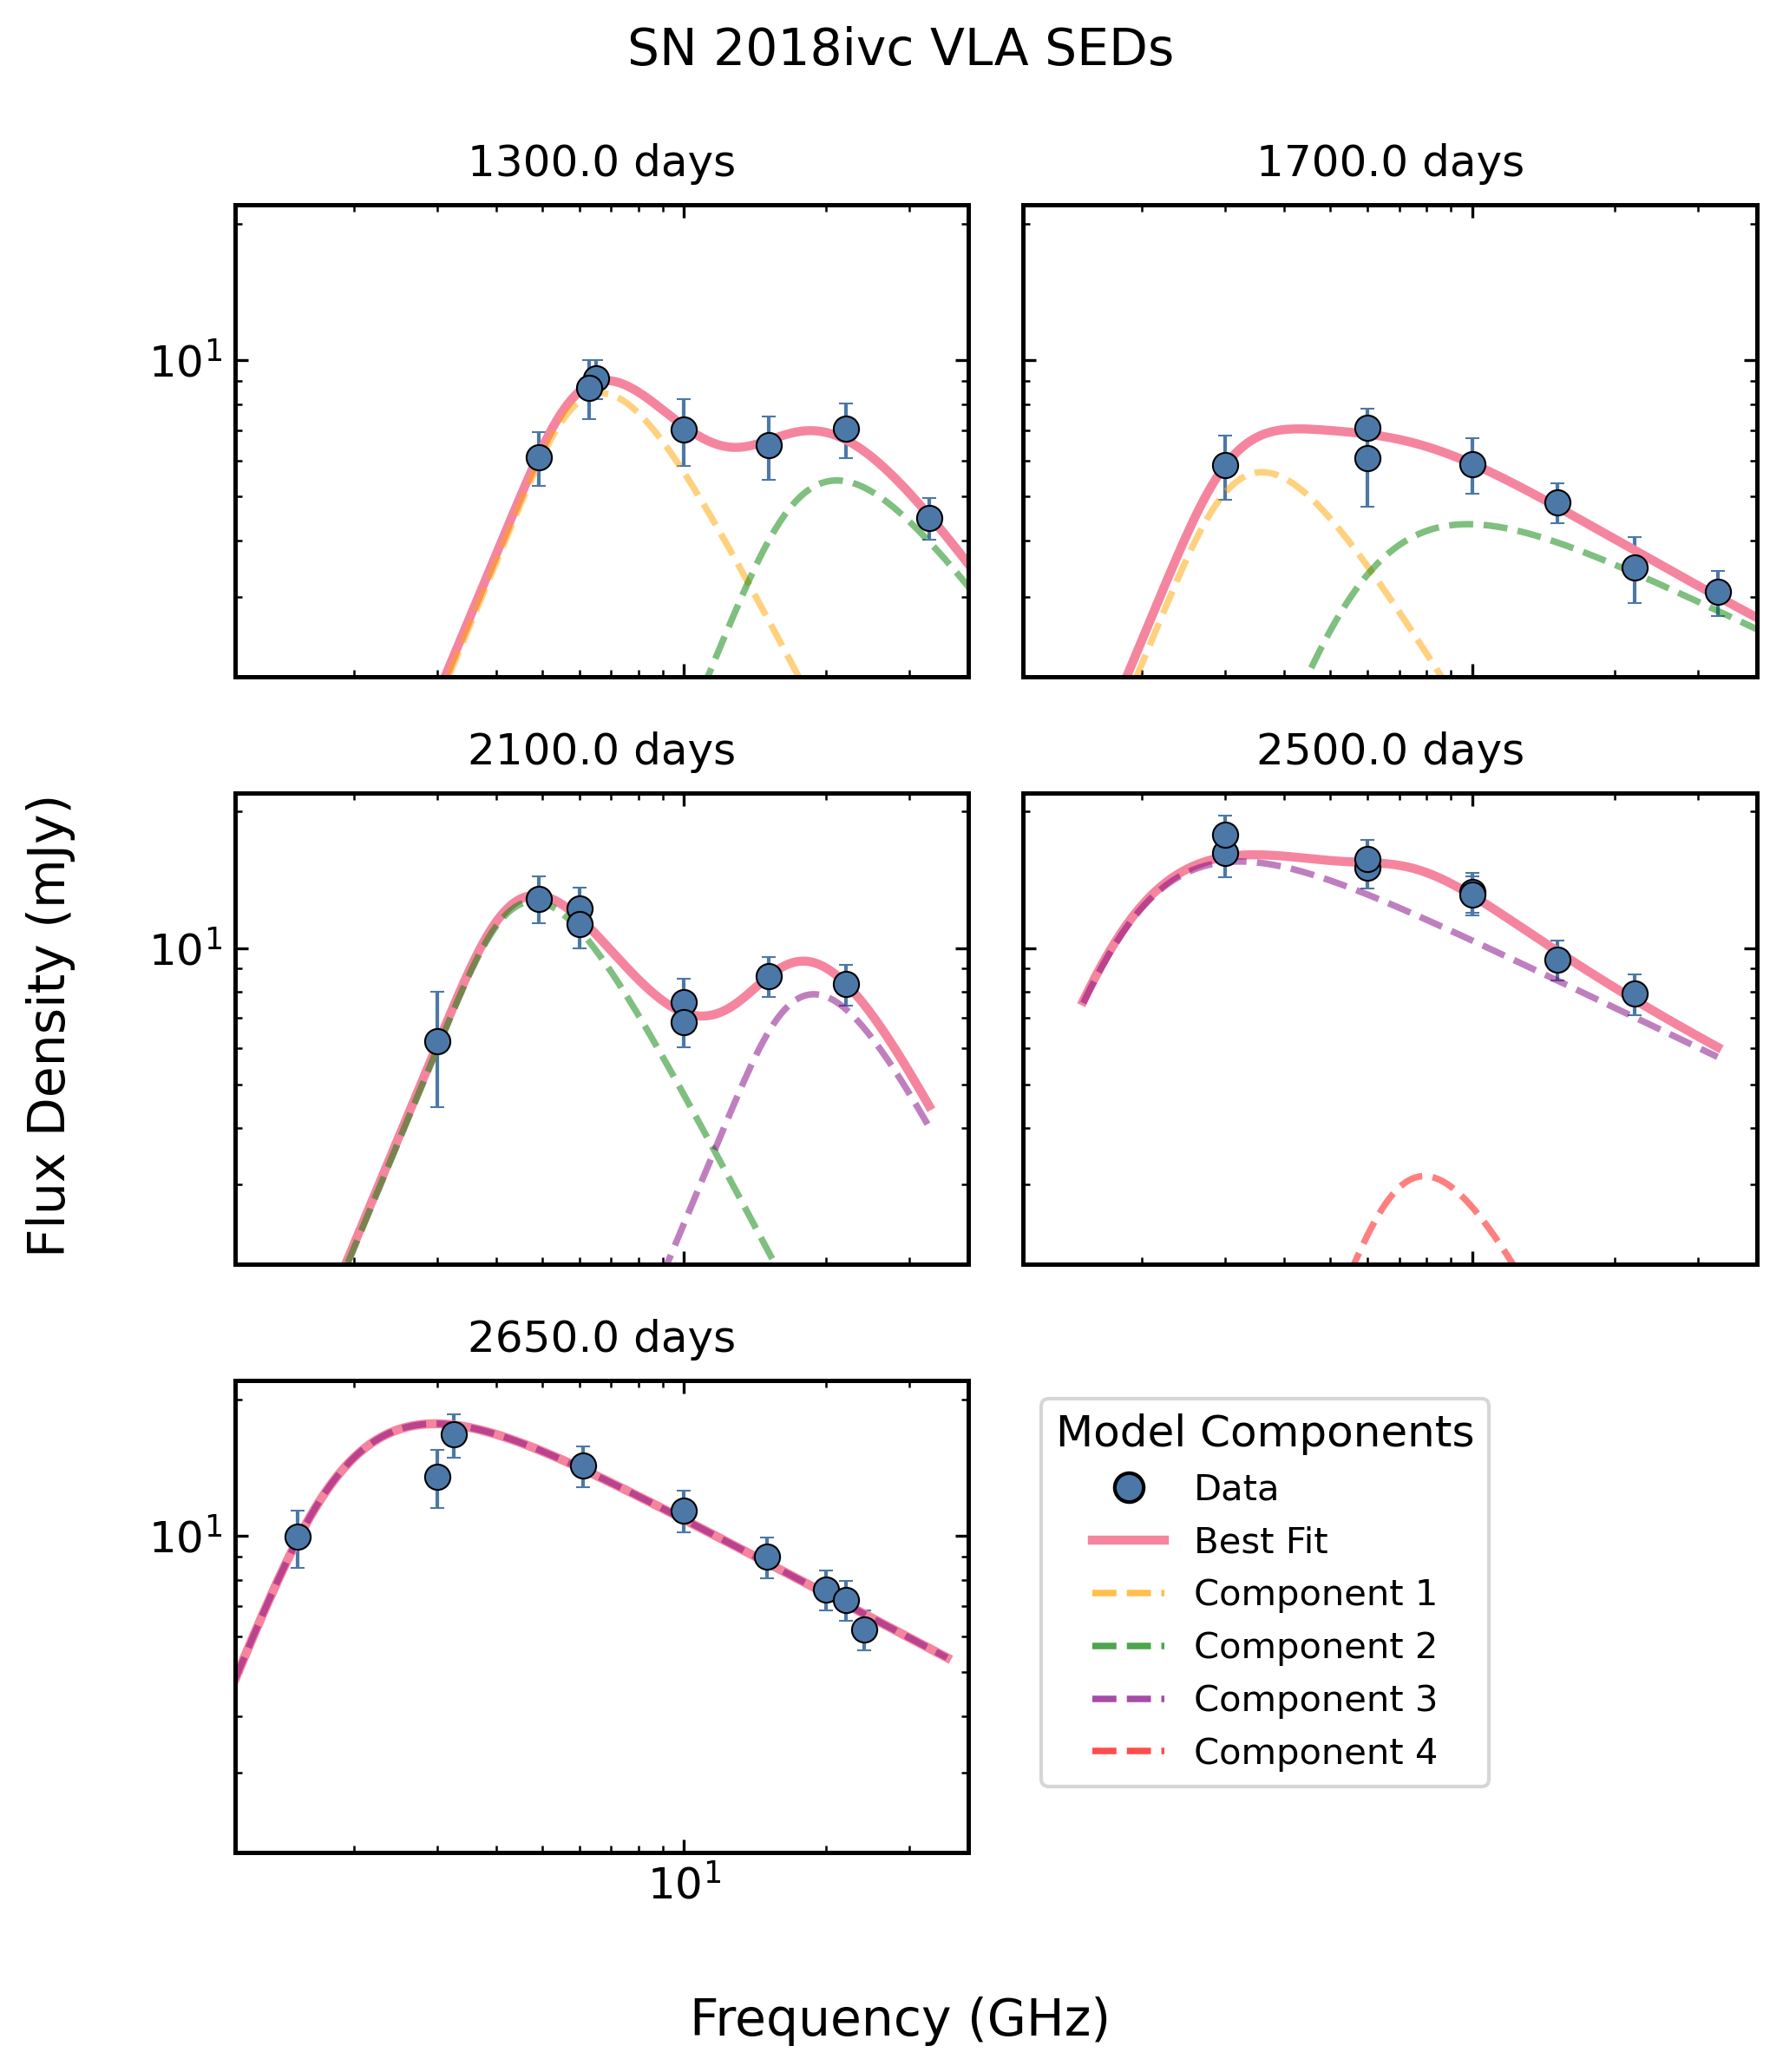

In [75]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

blue = "#4C78A8"
pink = "#F5859E"

color1 = 'orange'
color2 = 'green'
color3 = 'purple'
color4 = 'red'

# Define your epochs here
# Format:
# (phase_lower, phase_upper, avg_phase, closest_idx, best_fit_params, labels, colors)
epochs = [
    (1200, 1400, 1300.0, 1, [8.44397724245342,6.782679571348622,4.999999999999997,5.390828461554526,20.05438971340149,3.783907567649094], ["Component 1", "Component 2"], [color1, color2]),
    (1600, 1800, 1700.0, 1, [5.650142307272045,3.542448907893012,4.352396091522126,3.8722016614391706,6.924837077816746,2.0000000000008984], ["Component 1", "Component 2"], [color1, color2]),
    (2000, 2200, 2100.0, 1, [12.666491962990392,4.868843341487093,4.956659969496957,7.8940387389930065,19.135074867724068,4.999999999999999], ["Component 2", "Component 3"], [color2, color3]),
    (2350, 2550, 2500.0, 1, [13.855598352273423,2.2674048428453606,2.0000000000000004,3.129679551297325,8.043498213081852,4.999999999999999], ["Component 3", "Component 4"], [color3, color4]),
    (2550, 2750, 2650.0, 0, [16.01219376601599,2.17731177474123,2.1041442641418464], ["Component 3"], [color3]),
]

fig, axes = plt.subplots(3, 2, figsize=(7, 8), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

for ax, (phase_lower, phase_upper, avg_phase, closest_idx, best_fit_params, labels, colors) in zip(axes[:-1], epochs):
    data_epoch = data[
        (data["phase"] >= phase_lower) &
        (data["phase"] <= phase_upper)
    ]

    freq = data_epoch["freq"]
    flux = data_epoch["flux"]

    ax.errorbar(
        freq, flux,
        yerr=data_epoch["flux_err"],
        fmt="o",
        ms=7,
        capsize=2,
        elinewidth=1,
        color=blue,
        mec="black",
        mew=0.5,
        label="Data"
    )

    freq_range = np.logspace(
        np.log10(min(freq) * 0.5),
        np.log10(max(freq) * 1.5),
        200
    )

    if closest_idx == 0:
        best_fit = functions.F_SSA_Nayana(freq_range, *best_fit_params)
        ax.plot(freq_range, best_fit, color=pink, lw=2.5, label="Best Fit")

        comp1_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[0],
            best_fit_params[1],
            best_fit_params[2]
        )
        ax.plot(
            freq_range, comp1_curve,
            label=labels[0],
            color=colors[0],
            linestyle="--",
            alpha=0.5,
            lw=1.8
        )

    elif closest_idx == 1:
        best_fit = functions.F_SSA_Nayana_2comp(freq_range, *best_fit_params)
        ax.plot(freq_range, best_fit, color=pink, lw=2.5, label="Best Fit")

        comp1_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[0],
            best_fit_params[1],
            best_fit_params[2]
        )
        comp2_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[3],
            best_fit_params[4],
            best_fit_params[5]
        )

        ax.plot(freq_range, comp1_curve, label=labels[0],
                color=colors[0], linestyle="--", alpha=0.5, lw=1.8)
        ax.plot(freq_range, comp2_curve, label=labels[1],
                color=colors[1], linestyle="--", alpha=0.5, lw=1.8)

    else:
        best_fit = functions.F_SSA_Nayana_3comp(freq_range, *best_fit_params)
        ax.plot(freq_range, best_fit, color=pink, lw=2.5, label="Best Fit")

        comp1_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[0],
            best_fit_params[1],
            best_fit_params[2]
        )
        comp2_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[3],
            best_fit_params[4],
            best_fit_params[5]
        )
        comp3_curve = functions.F_SSA_Nayana(
            freq_range,
            best_fit_params[6],
            best_fit_params[7],
            best_fit_params[8]
        )

        ax.plot(freq_range, comp1_curve, label=labels[0],
                color=colors[0], linestyle="--", alpha=0.5, lw=1.8)
        ax.plot(freq_range, comp2_curve, label=labels[1],
                color=colors[1], linestyle="--", alpha=0.5, lw=1.8)
        ax.plot(freq_range, comp3_curve, label=labels[2],
                color=colors[2], linestyle="--", alpha=0.5, lw=1.8)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1.12, 40.0)
    ax.set_ylim(2.0, 22.0)

    # larger individual subplot titles
    ax.set_title(f"{avg_phase:.1f} days", fontsize=12, pad=8)

fig.supxlabel("Frequency (GHz)", fontsize=14)
fig.supylabel("Flux Density (mJy)", fontsize=14)
fig.suptitle("SN 2018ivc VLA SEDs", fontsize=14)

# Use bottom-right panel for master legend
colors = [color1, color2, color3, color4]
labels = ["Component 1", "Component 2", "Component 3", "Component 4"]

legend_ax = axes[-1]
legend_ax.axis("off")

legend_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=blue, markeredgecolor="black",
           markersize=8, label="Data"),
    Line2D([0], [0], color=pink, lw=2.5, label="Best Fit"),
    Line2D([0], [0], color=colors[0], lw=1.8,
           linestyle="--", alpha=0.7, label=labels[0]),
    Line2D([0], [0], color=colors[1], lw=1.8,
           linestyle="--", alpha=0.7, label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=1.8,
           linestyle="--", alpha=0.7, label=labels[2]),
    Line2D([0], [0], color=colors[3], lw=1.8,
           linestyle="--", alpha=0.7, label=labels[3]),
]

legend_ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    fontsize=10,
    title="Model Components",
    title_fontsize=12
)

fig.tight_layout()
fig.savefig("figures/sed_subplots.png", bbox_inches="tight", dpi=300)
plt.show()